# Ecuaciones diferenciales

### Solución sobre valores o rangos infinitos

Hasta el momento, hemos encontrado la solución diferencial de un punto inicial desde una condición inical a una distancia finita en t, pero en algunos casos, necesitamos mapear $t\rightarrow\infty$. Algo de naturaleza asintótica.

Si hacemos un cambio de variable:

$$u=\frac{t}{1+t}$$

$$t=\frac{u}{1-u}$$

De esta manera mientras $t\rightarrow\infty$ entonces  $u\rightarrow 1$.

Ahora tenemos que encontrar la diferencial usando esta variable para posteriormente integrar. Por regla de la cadena tenemos que:

$$\frac{dx}{dt}=\frac{dx}{du}\frac{du}{dt}  = f(x,t)$$
$$\frac{dx}{du} =\frac{dt}{du}f(x,\frac{u}{1-u})$$
pero, $$\frac{dt}{du}=\frac{1}{(1-u)^2}$$
Entonces, 
$$
\frac{dx}{du}=\frac{1}{(1-u)^2}f(x,\frac{u}{1-u})
$$

Definimos una nueva función

$$
g(x,u)=(1-u)^{-2}f(x,\frac{u}{1-u})
$$

y la ecuación diferencial a programar es

$$
\frac{dx}{du}=g(x,u)
$$

Digamos que tenemos la siguiente ecuación:

$$
\frac{dx}{dt} = \frac{1}{x^2+t^2}
$$

Y la queremos resolver, $t$ va de cero a infinito y ponemos como condición inicial en $x$ que sea igual a uno cuando $t=0$ Encuentra $g(x,u)$ y escribe su expresion en la casilla de abajo.

# Respuesta aqui!

Ahora acompleta el código (Runge-Kutta de orden 4) para resolverla. 

/srv/conda/envs/notebook/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in double_scalars
  after removing the cwd from sys.path.
/srv/conda/envs/notebook/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in double_scalars
  after removing the cwd from sys.path.


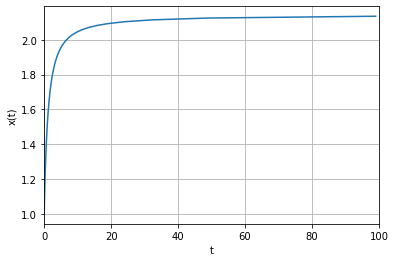

In [23]:
from pylab import *

def g(x,u):
    return 1/((1-u)**2*(x**2+(u/(1-u))**2))

a,b=0,1 ####poner rango####

N=100
h=(b-a)/N
lista_u=arange(a,b,h)
lista_t,lista_x=[],[]
x=1 #####aqui valor inicial#####
for u in lista_u:
    lista_t.append(u/(1-u)) #para plotear con respecto a t
    lista_x.append(x)
    k1=h*g(x,u)
    k2=h*g(x+0.5*k1,u+0.5*h)
    k3=h*g(x+0.5*k2,u+0.5*h)
    k4=h*g(x+k3,u+h)
    x+=(k1+2*k2+2*k3+k4)/float(6)
plot(lista_t,lista_x)
xlim(0,100)
grid(True)
xlabel('t')
ylabel('x(t)')
show()

## Ecuaciones Diferenciales con más de una variable 

Digamos que tenemos un sistema de ecuaciones diferenciales simultaneas donde la derivada de cada variable puede depender del resto. Un ejemplo es:

$$
\frac{dx}{dt}= xy-x, \frac{dy}{dt}=y-xy+sin^2(wt)
$$

Donde $t$ sigue siendo la única variable independiente. Noten que son ecuaciones diferenciales ordinarias, no son ecuaciones diferenciales parciales!!

Podemos expresar el sistema de forma más general como:

$$
\frac{dx}{dt}= f_x(x,y,t), \frac{dy}{dt}=f_y(x,y,t)
$$

Para un número arbitrario de variables estas ecuaciones se pueden generalizar usando notación vectorial.

$$
\frac{d\mathbf{r}}{dt} = \mathbf{f}(\mathbf{r},t)
$$

Donde $\mathbf{r} = (x,y,\ldots)$ y $\mathbf{f} = (f_x(\mathbf{r},t), f_y(\mathbf{r},t), \ldots)$

Podemos obtener de el método de Euler para varias variables de la siguiente forma (expandimos en serie de Taylor):

$$
\mathbf{r}(t+h)=\mathbf{r}(t)+h\frac{d\mathbf{r}}{dt}+O(h^2)\\
       =\mathbf{r}(t)+h\mathbf{f}(x,t)+O(h^{2})
$$

Ignorando términos de orden cuadrático obtenemos por fín el método de Euler multivariable:

$$
\mathbf{r}(t+h)=\mathbf{r}(t)+h\mathbf{f}(x,t)
$$

Y de la misma manera se puede generalizar Runge-Kutta:

$$
\mathbf{k_1}=h\mathbf{f}(\mathbf{r},t)
$$

$$
\mathbf{k_2}=h\mathbf{f}(\mathbf{r}+0.5\mathbf{k_1},t+0.5h)
$$

$$
\mathbf{k_3}=h\mathbf{f}(\mathbf{r+}0.5\mathbf{k_2},t+0.5h)
$$

$$
\mathbf{k_4}=h\mathbf{f}(\mathbf{r}+\mathbf{k_3},t+h)
$$

$$
\mathbf{r(t+h)}=\mathbf{r}(t)+\frac{(\mathbf{k_1+2k_2+2k_3+k_4)}}{6.}
$$

Resuelve la expresión al inicio de esta sección en el rango $t=0$ hasta $t=10$ usando $\omega=1$ y con condiciones iniciales $x=y=1$ en $t=0$:

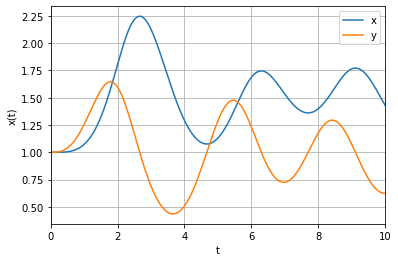

In [24]:
from pylab import *
def f(r,t):
    x=r[0]
    y=r[1]
    fx=x*y-x
    fy=y-x*y+(sin(t))**2
    return array([fx,fy],float)
a,b=0.0,10.0
N=1000
h=(b-a)/N
lista_t=arange(a,b,h)
lista_x,lista_y=[],[]
r=array([1.0,1.0],float) #condiciones iniciales
for t in lista_t:
    lista_x.append(r[0])
    lista_y.append(r[1])
    k1=h*f(r,t)
    k2=h*f(r+0.5*k1,t+0.5*h)
    k3=h*f(r+0.5*k2,t+0.5*h)
    k4=h*f(r+k3,t+h)
    r+=(k1+2*k2+2*k3+k4)/float(6)
plot(lista_t,lista_x, label='x')
plot(lista_t,lista_y, label='y')
xlim(0,10)
grid(True)
xlabel('t')
ylabel('x(t)')
legend()
show()

## Módelo depredador y presa (Lotka-Volterra)

Es interesante para representar interacciones de depredador-presa en sistemas biológicos.

Tradicionalmente se habla de conejos (presa, $x$) y zorros (depredador, $y$). Las cantidades $x,y$ se piensan normalmente en los miles.

Los conejos se reproducen en una tasa proporcional a su población misma, pero son devorados en una tasa proporcional a su población y a la población de zorros:


$$
\frac{dx}{dt} = \alpha x - \beta x y
$$

Donde $\alpha$ y $\beta$ son constantes. A su vez los zorros se reproducen a una tasa proporcional a la tasa que devoran conejos, pero se mueren a una tasa proporcional a su población misma (por edad avanzada).

$$
\frac{dy}{dt} = \gamma x y - \delta y
$$

a) Escribe un programa para resolver estas ecuaciones usando Runge-Kutta de cuarto orden para el caso $\alpha=1$, $\beta=\gamma=0.5$ y $\delta = 2$ empezando de la condición inicial $x=y=2$ (i.e. 2000 conejos y dos mil zorros). Has que el programa haga una gráfica mostrando tanto $x$ como $y$ como función del tiempo usando como mismo eje $t$ que vaya desde cero hasta 30. NOTA: A pesar de que no hay dependencia explícita de $t$ es conveniente escribir la función de la forma $f(\mathbf{r},t)$ incluyendo la variable temporal para no tener que reescribir nada.

b) plotea zorros vs conejos.

c) describe lo que sucede usando ambas gráficas en términos de zorros y conejos.

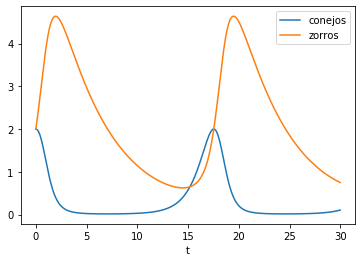

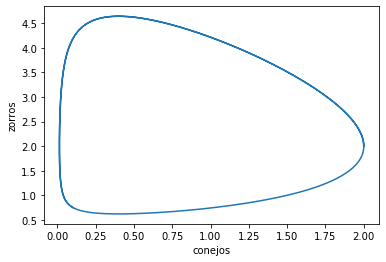

In [26]:
from pylab import *
def f(r,t):
    x=r[0]
    y=r[1]
    fx=alpha*x-beta*x*y
    fy=gamma*x*y-delta*y
    return array([fx,fy],float)

a,b=0.0,30.0
N=1000
h=(b-a)/N
lista_t=arange(a,b,h)
lista_x,lista_y=[],[]
r=array([2.0,2.0],float) #condiciones iniciales
alpha,beta,gamma,delta=1.0,0.5,0.5,0.2
for t in lista_t:
    lista_x.append(r[0])
    lista_y.append(r[1])
    k1=h*f(r,t)
    k2=h*f(r+0.5*k1,t+0.5*h)
    k3=h*f(r+0.5*k2,t+0.5*h)
    k4=h*f(r+k3,t+h)
    r+=(k1+2*k2+2*k3+k4)/float(6)
plot(lista_t,lista_x,label='conejos')
plot(lista_t,lista_y,label='zorros')
legend()
xlabel('t')
show()
plot(lista_x,lista_y) #espacio fase
xlabel('conejos')
ylabel('zorros')
show()

En la primera gráfica donde graficamos tanto conejos como zorros en función del tiempo, vemos que en principio, conforme los zorros aumentan, la población de conejos disminuye, pues al haber más zorros, los conejos son más depredados; sin embargo, la población de zorros llega a un máximo, debido al término $ -\delta y$ y la de conejos llega a un mínimo. Al ir disminuyendo la población de zorros, ya no hay tantos que se coman a los conejos y esto permite que su población crezca; pero al haber más conejos, interactúan más con los zorros (el término $\gamma xy$ en la ecuación para $\frac{dy}{dt}$), con lo cual, la población de zorros vuelve a aumentar y frena el crecimiento de la población de conejos, y nuevamente se repite el proceso: la población de conejos disminuye conforme la de zorros aumenta hasta llegar a máximos y mínimos). De hecho si extendemos el intervalo de la gráfica podemos apreciar cómo se repite el comportamiento.

Por otro lado en la gráfica del espacio fase tenemos que para las condiciones iniciales que tomamos en este caso, el comportamiento de las poblaciones de zorros y conejos es cíclico, es decir, se repite con el paso del tiempo, lo cual es representado en el espacio fase por la curva cerrada que observamos, de hecho, dicha curva debe tener un 'sentido' para recorrerse. Según nuestras condiciones inciales, comenzamos en el punto (2,2), luego de acuerdo a la primera gráfica, la población de zorros aumenta y la de conejos disminuye, por lo que la curva comienza a recorrerse en el sentido antihorario, y eventualmente las poblaciones regresarán al mismo punto de inicio para volver a recorrer la curva nuevamente.

# Ecuaciones de Lorenz

De las ecuaciones diferenciales más conocidas:

$$
\frac{dx}{dt}=\sigma(y-x), \frac{dy}{dt}=rx-y-xz, \frac{dz}{dt}=xy-bz
$$

Donde $\sigma, r$ y $b$ son constantes.

Estudiadas por Edward Lorenz en 1963, para estudiar patrones de clima simplificados. Son famosas por ser de los primeros ejemplos de caos determinista, apariencia de movimiento aleatorio a pesar de que no hay aleatoridad en las ecuaciones.

a) Escribe un programa para resolver las ecuaciones de Lorenz (usando Runge-Kutta de orden 4) para el caso $\sigma=10, r=28$ y $b=\frac{8}{3}$ donde t va de 0 a 50 con las condiciones iniciales $(x,y,z) = (0,1,0)$. Haz que el programa grafique $y$ como función del tiempo.

b) Modifica tu programa para producir una gráfica de $z$ vs $x$. Deberías de ver el famoso atractor extraño  de las ecuaciones de Lorenz.

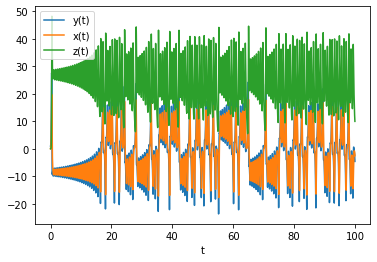

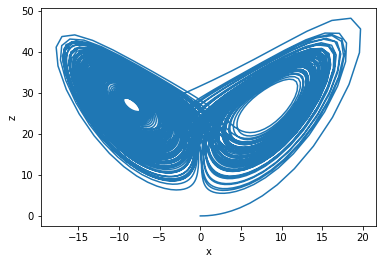

In [27]:
from pylab import *
def f(r,t):
    x=r[0]
    y=r[1]
    z=r[2]
    fx=sigma*(y-x)
    fy=rho*x-y-x*z
    fz=x*y-beta*z
    return array([fx,fy,fz],float)

a,b=0.0,100.0
N=5000
h=(b-a)/N
lista_t=arange(a,b,h)
lista_x,lista_y,lista_z=[],[],[]
r=array([0.0,1.0,0.0],float)
sigma,rho,beta=10.0,28.0,float(8/3)
for t in lista_t:
    lista_x.append(r[0])
    lista_y.append(r[1])
    lista_z.append(r[2])
    k1=h*f(r,t)
    k2=h*f(r+0.5*k1,t+0.5*h)
    k3=h*f(r+0.5*k2,t+0.5*h)
    k4=h*f(r+k3,t+h)
    r+=(k1+2*k2+2*k3+k4)/float(6)
plot(lista_t,lista_y,label='y(t)')
plot(lista_t,lista_x,label='x(t)')
plot(lista_t,lista_z,label='z(t)')
xlabel('t')
legend()
show()
plot(lista_x,lista_z)
xlabel('x')
ylabel('z')
show()